Annualized Volatility: 0.6011

=== Key Results Summary ===
       Latest Close Price  20-Day SMA  RSI (14)    MACD  MACD Signal  \
Value              103.73     122.038   33.3497 -2.9541      -0.3894   

       MACD Histogram  Latest Daily Return  Cumulative Return  \
Value         -2.5647              -0.0704          2528.0131   

       Annualized Volatility  
Value                 0.6011  


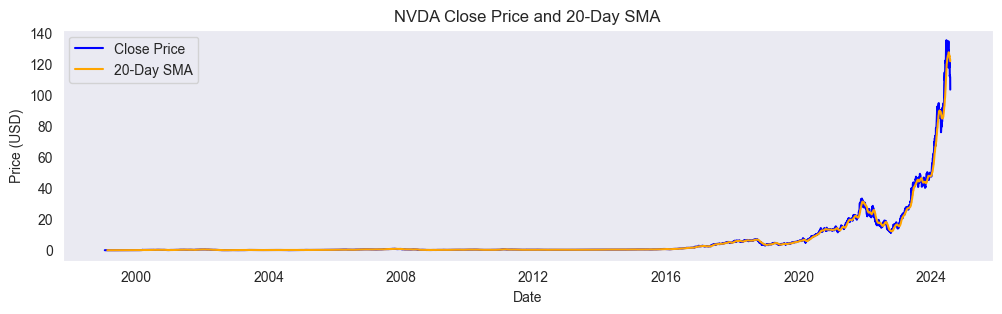

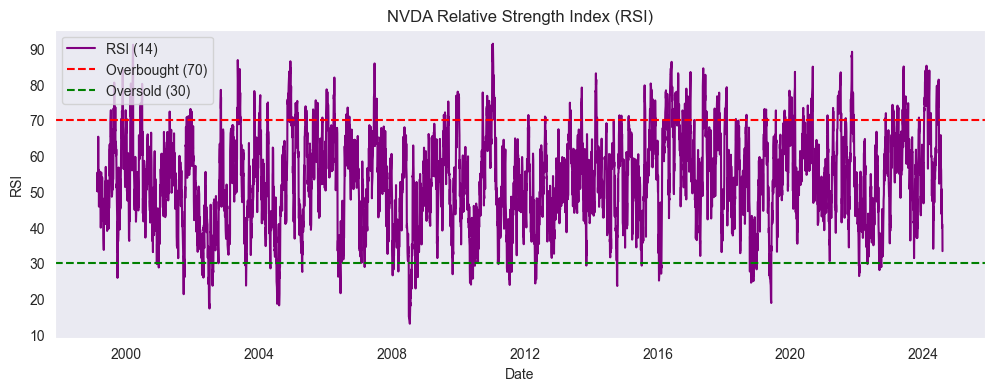

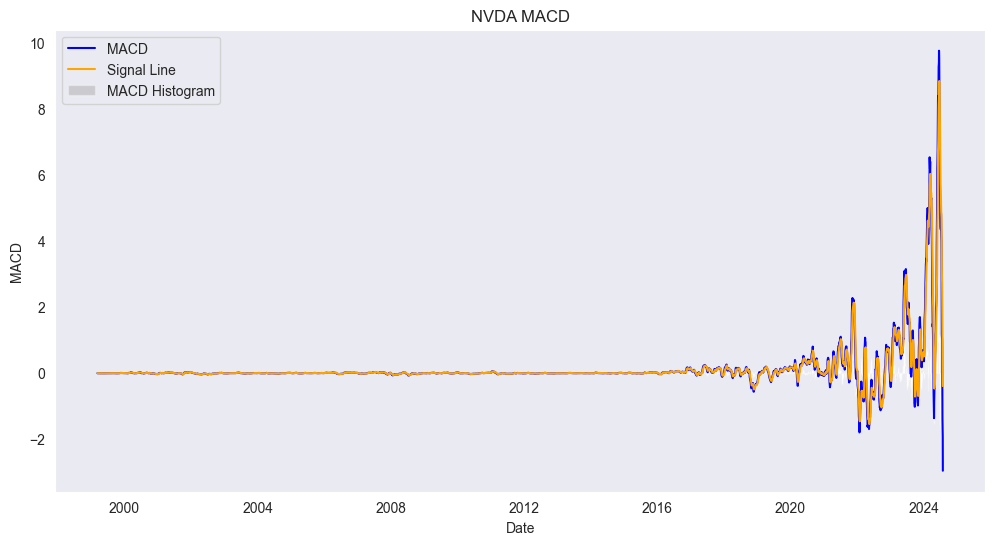

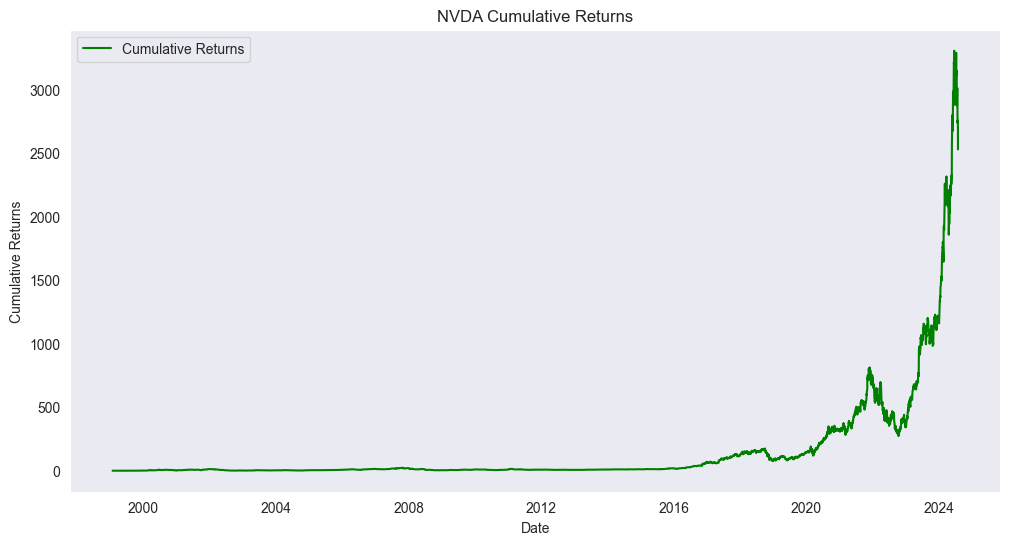

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_style('dark')
%matplotlib inline

# Create visualizations folder for NVDA
visualizations_dir = '../notebooks/visualizations/NVDA'
os.makedirs(visualizations_dir, exist_ok=True)

# Load and prepare data
data_path = '../data/yfinance_data/NVDA_historical_data.csv'
df = pd.read_csv(data_path)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Ensure required columns are present
required_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
if not all(col in df.columns for col in required_columns):
    raise ValueError(f"Data must contain columns: {required_columns}")

# Calculate Technical Indicators with TA-Lib
# Simple Moving Average (SMA)
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)

# Relative Strength Index (RSI)
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

# Moving Average Convergence Divergence (MACD)
df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = talib.MACD(
    df['Close'], fastperiod=12, slowperiod=26, signalperiod=9
)

# Calculate financial metrics
# Calculate daily returns using pandas
df['Returns'] = df['Close'].pct_change()

# Calculate annualized volatility using pandas and numpy
volatility = df['Returns'].std() * np.sqrt(252)
print(f"Annualized Volatility: {volatility:.4f}")

# Calculate cumulative returns
df['Cumulative_Returns'] = (1 + df['Returns']).cumprod() - 1

# Key Results Summary
print("\n=== Key Results Summary ===")
latest_data = df.iloc[-1]  # Latest row of data
summary = {
    'Latest Close Price': latest_data['Close'],
    '20-Day SMA': latest_data['SMA_20'],
    'RSI (14)': latest_data['RSI_14'],
    'MACD': latest_data['MACD'],
    'MACD Signal': latest_data['MACD_Signal'],
    'MACD Histogram': latest_data['MACD_Hist'],
    'Latest Daily Return': latest_data['Returns'],
    'Cumulative Return': latest_data['Cumulative_Returns'],
    'Annualized Volatility': volatility
}
summary_df = pd.DataFrame(summary, index=['Value']).round(4)
print(summary_df)

# Visualize the Data
# Plot 1: Close Price and SMA
plt.figure(figsize=(12, 3))
plt.plot(df.index, df['Close'], label='Close Price', color='blue')
plt.plot(df.index, df['SMA_20'], label='20-Day SMA', color='orange')
plt.title('NVDA Close Price and 20-Day SMA')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left')
plt.savefig(os.path.join(visualizations_dir, 'nvda_close_sma.png'))
plt.show()

# Plot 2: RSI
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['RSI_14'], label='RSI (14)', color='purple')
plt.axhline(y=70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(y=30, color='green', linestyle='--', label='Oversold (30)')
plt.title('NVDA Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend(loc='upper left')
plt.savefig(os.path.join(visualizations_dir, 'nvda_rsi.png'))
plt.show()

# Plot 3: MACD
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['MACD'], label='MACD', color='blue')
plt.plot(df.index, df['MACD_Signal'], label='Signal Line', color='orange')
plt.bar(df.index, df['MACD_Hist'], label='MACD Histogram', color='gray', alpha=0.3)
plt.title('NVDA MACD')
plt.xlabel('Date')
plt.ylabel('MACD')
plt.legend(loc='upper left')
plt.savefig(os.path.join(visualizations_dir, 'nvda_macd.png'))
plt.show()

# Plot 4: Cumulative Returns
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cumulative_Returns'], label='Cumulative Returns', color='green')
plt.title('NVDA Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend(loc='upper left')
plt.savefig(os.path.join(visualizations_dir, 'nvda_cumulative_returns.png'))
plt.show()